<a href="https://colab.research.google.com/github/WajdAlsuhaymi/IT326-DataMining-Group2/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 – Data Summarization and Preprocessing

This phase focuses on analyzing and preparing the dataset before applying data mining techniques.
It includes summarizing data, visualizing relationships, handling missing values, and applying preprocessing techniques such as encoding, normalization, and outlier removal.

### **Part** 1 : Data Summarization

In [ ]:

# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Loading the Dataset
url='https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv'
df = pd.read_csv(url)
df.head()


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [ ]:
# General Information and Missing Values
print("Dataset Shape:", df.shape)
df.info()

# Missing values summary
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)


Dataset Shape: (924, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     924 non-null    float64
 1   Age                         924 non-null    float64
 2   Gender                      924 non-null    object 
 3   Platform                    924 non-null    object 
 4   Daily_Usage_Time (minutes)  924 non-null    float64
 5   Posts_Per_Day               924 non-null    float64
 6   Likes_Received_Per_Day      924 non-null    float64
 7   Comments_Received_Per_Day   924 non-null    float64
 8   Messages_Sent_Per_Day       924 non-null    float64
 9   Dominant_Emotion            924 non-null    object 
dtypes: float64(7), object(3)
memory usage: 72.3+ KB


,0


In [ ]:
# Statistical Summary
df.describe().T  # Includes five-number summary for numeric columns


,count,mean,std,min,25%,50%,75%,max
User_ID,924.0,498.937229,291.713692,1.0,231.75,500.5,731.25,1000.0
Age,924.0,27.500000,3.941473,21.0,24.00,27.0,30.00,35.0
Daily_Usage_Time (minutes),924.0,96.309524,39.228274,40.0,65.00,85.0,120.00,200.0
Posts_Per_Day,924.0,3.349567,1.940080,1.0,2.00,3.0,5.00,8.0
Likes_Received_Per_Day,924.0,40.246753,26.799196,5.0,19.50,33.0,55.00,110.0
Comments_Received_Per_Day,924.0,15.726190,8.933589,2.0,8.00,14.0,22.00,40.0
Messages_Sent_Per_Day,924.0,22.595238,8.634295,8.0,17.00,22.0,28.00,50.0


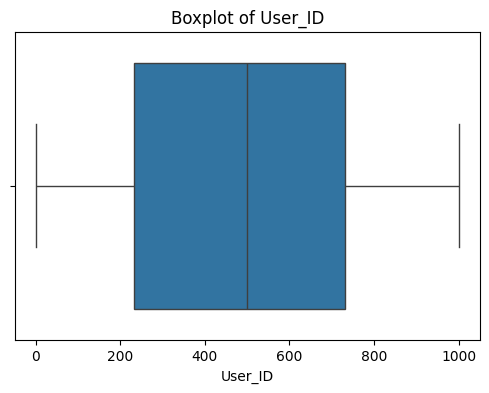

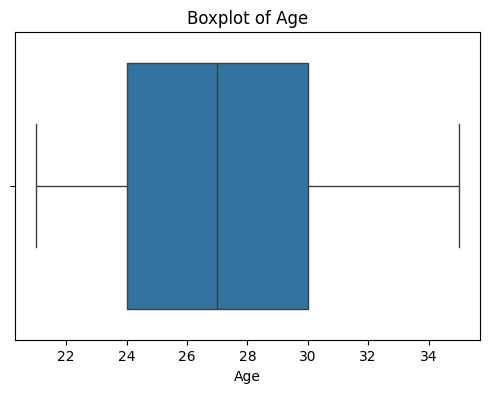

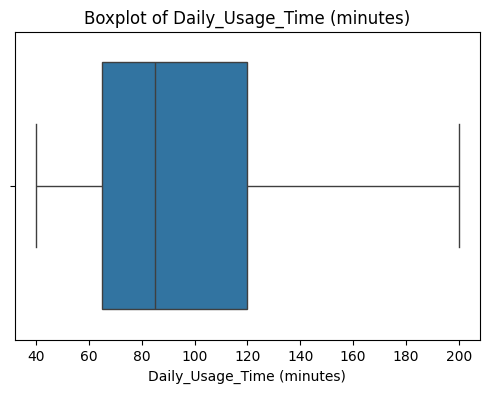

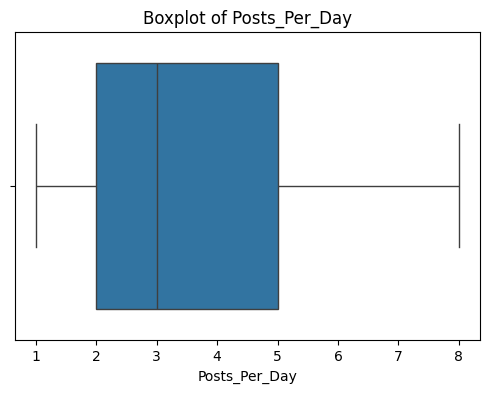

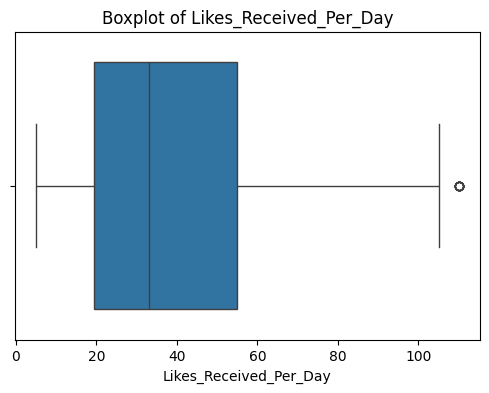

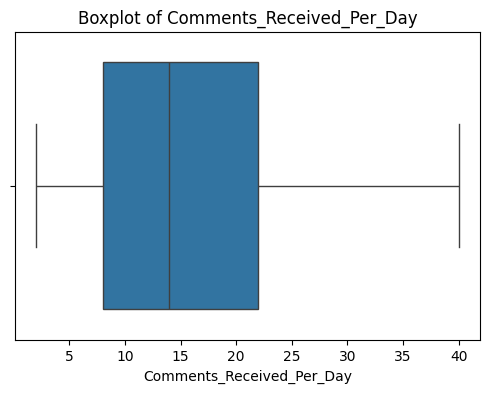

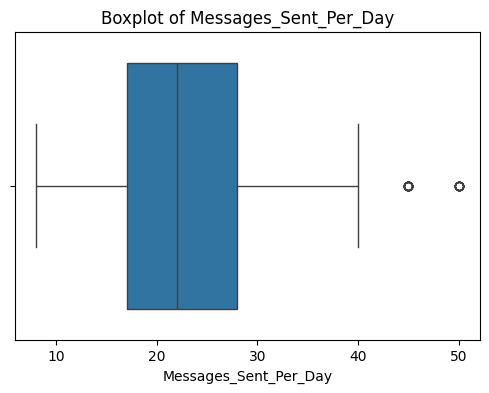

In [ ]:
# Boxplots and Outlier Detection
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()


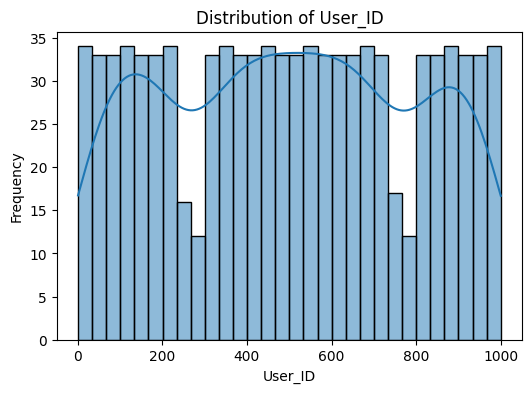

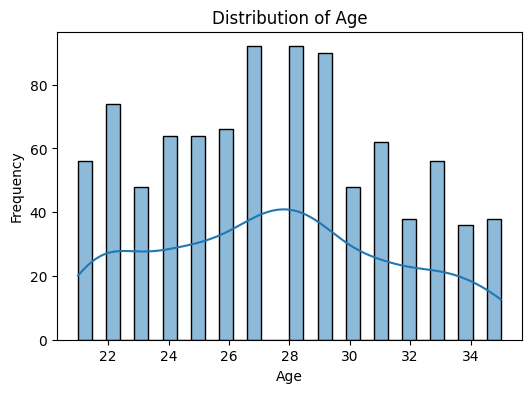

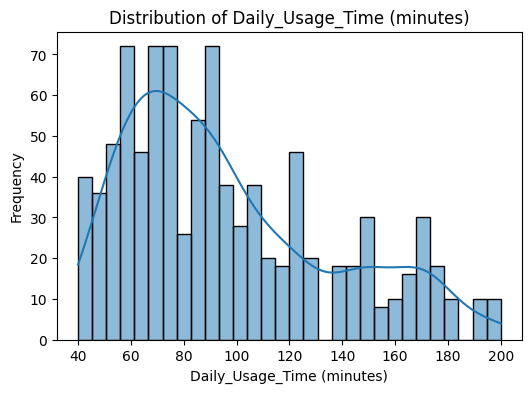

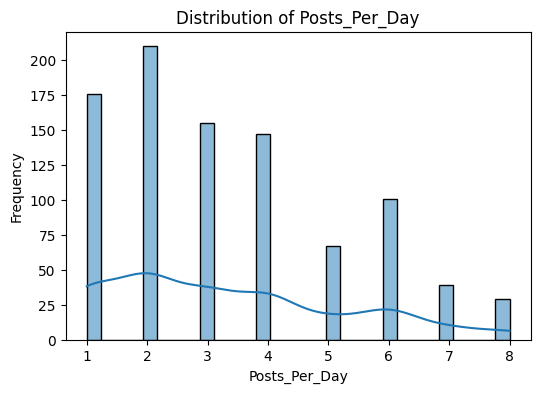

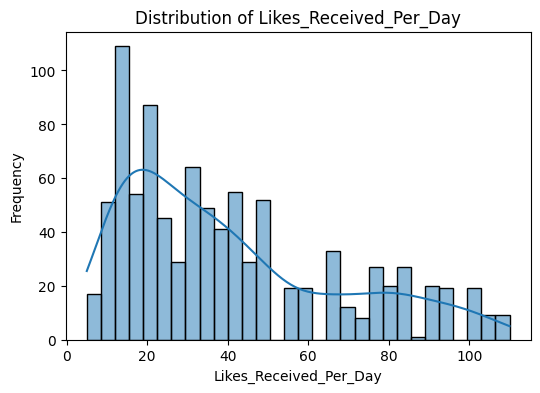

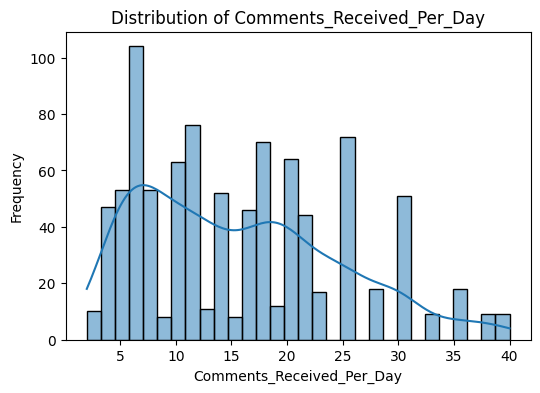

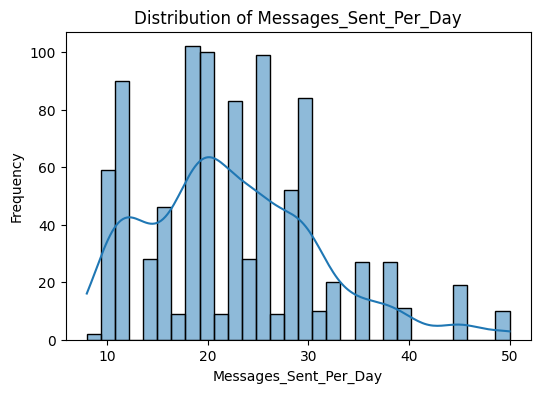

In [ ]:
# Histograms for Numeric Distributions
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


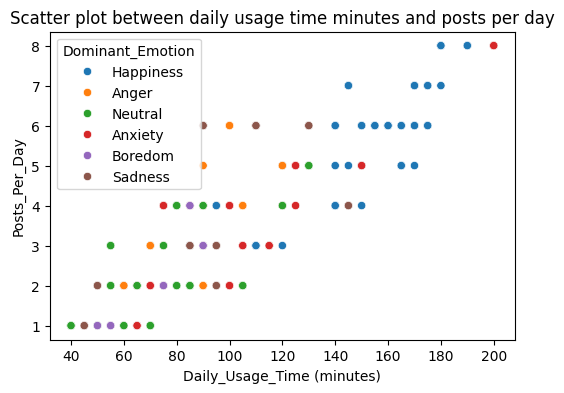

In [ ]:
# Scatter Plot (Pairwise Comparison)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Daily_Usage_Time (minutes)', y='Posts_Per_Day', hue='Dominant_Emotion')
plt.title('Scatter plot between daily usage time minutes and posts per day')
plt.show()


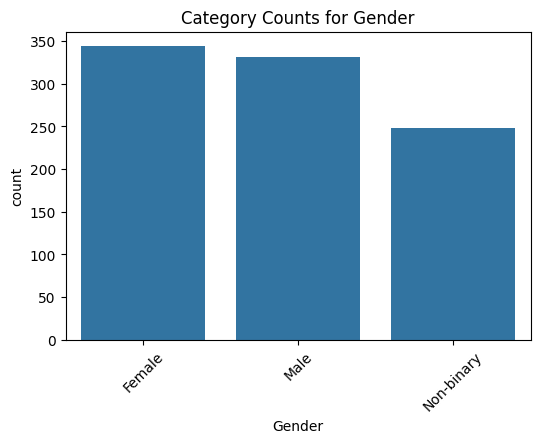

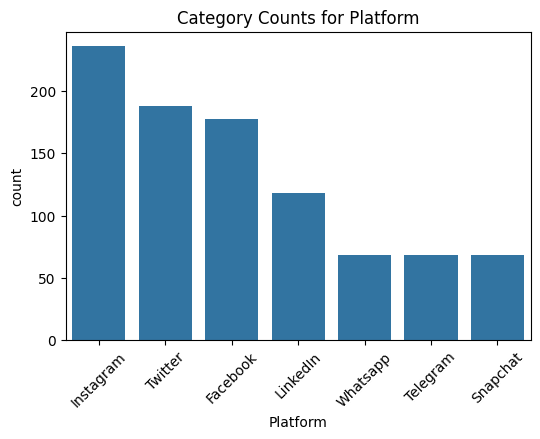

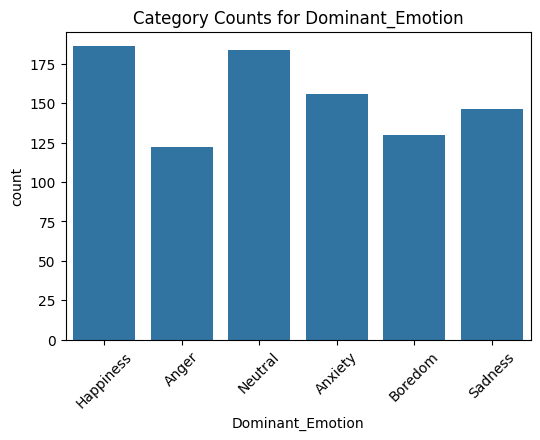

In [ ]:
# Bar Plots for Categorical Features
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Category Counts for {col}')
    plt.xticks(rotation=45)
    plt.show()


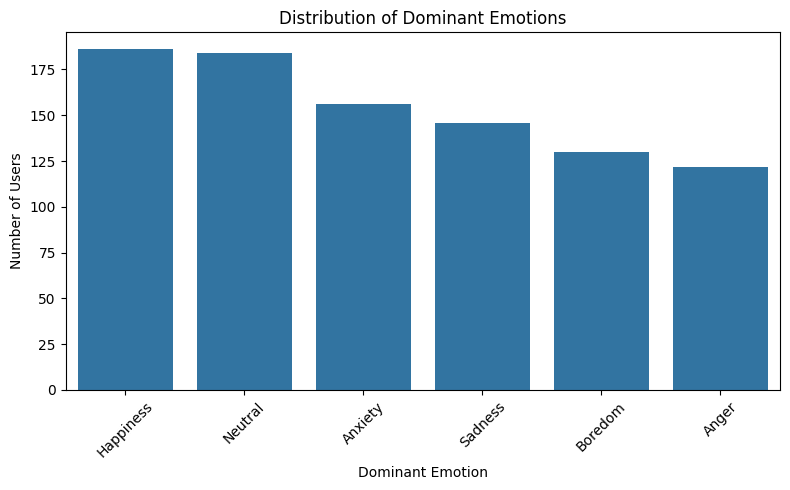

In [ ]:
# Class Label Distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Dominant_Emotion', order=df['Dominant_Emotion'].value_counts().index)
plt.title('Distribution of Dominant Emotions')
plt.xlabel('Dominant Emotion')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


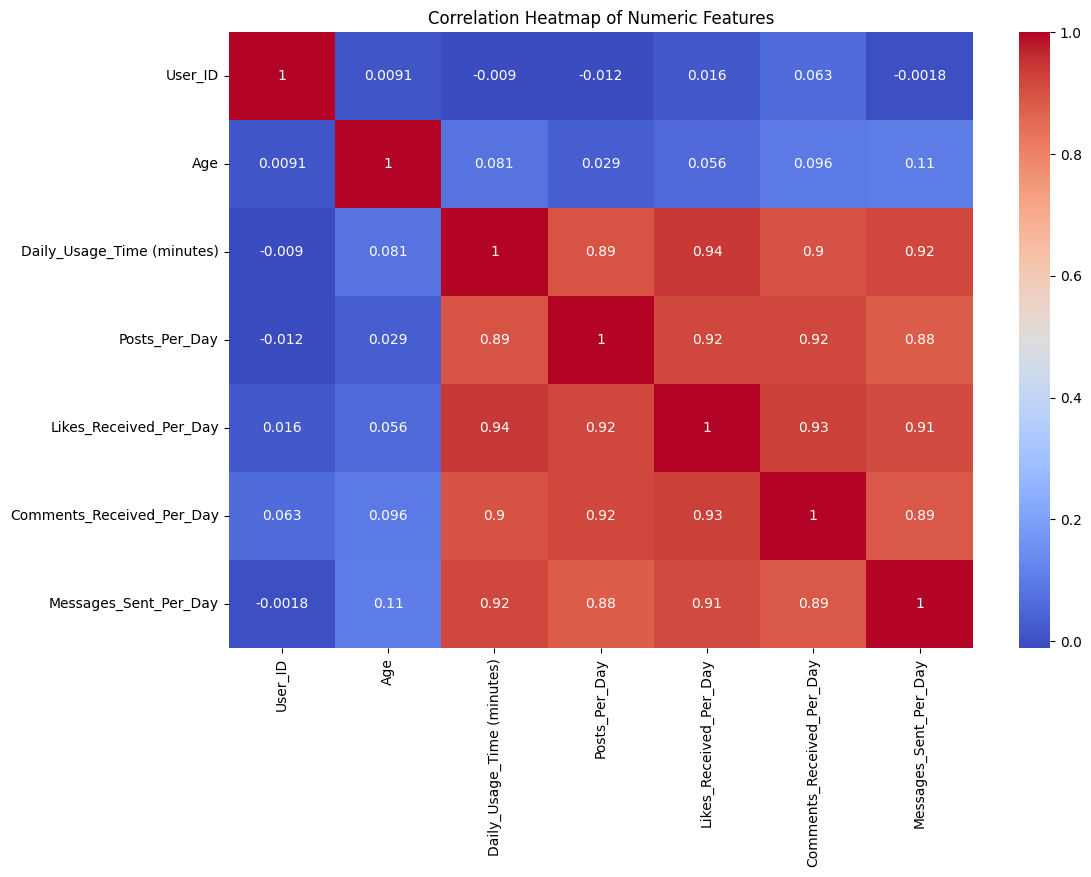

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


### **Part 2**: Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## Handling Missing Values

We used mean to fill missing numeric values and mode for categorical columns (Gender, Platform, Dominant_Emotion).
This was done to avoid losing rows and keep the dataset complete for analysis









In [ ]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv")

# Drop any completely empty rows
df = df.dropna(how='all')

print("Shape after dropping empty rows:", df.shape)

# Create a new DataFrame for preprocessing
df_processed = df.copy()

print("A new copy 'df_processed' is created for preprocessing.")
df_processed.head()


Shape after dropping empty rows: (924, 10)
A new copy 'df_processed' is created for preprocessing.


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [ ]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv")

# Drop any completely empty rows
df = df.dropna(how='all')

# Create a new dataset for preprocessing
df_processed = df.copy()

# Define numeric columns
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# Convert numeric columns to proper numeric dtype
df_processed[numeric_cols] = df_processed[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing numeric values with mean for each column
for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

print("✔ Numeric columns cleaned and missing values filled successfully!")
df_processed.head()


✔ Numeric columns cleaned and missing values filled successfully!


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## 1) Loading the Raw Dataset
We loaded the raw dataset and removed any completely empty rows to ensure data consistency before preprocessing.

In [ ]:
import pandas as pd

# تحميل الداتا من الراو مرّة واحدة
df = pd.read_csv("https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv")

# حذف الصفوف الفارغة بالكامل (احتياطي)
df = df.dropna(how='all')

# إنشاء نسخة للبروسسينق
df_processed = df.copy()

print("Shape:", df_processed.shape)
df_processed.head()


Shape: (924, 10)


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## 2) Cleaning Numeric Attributes
We converted all numeric attributes to proper numerical format and filled missing values using the mean of each column.
This ensures that the dataset contains no null values and remains suitable for machine learning algorithms.

In [ ]:
# تعريف الأعمدة الرقمية
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# تحويل للأرقام (احتياط)
df_processed[numeric_cols] = df_processed[numeric_cols].apply(pd.to_numeric, errors='coerce')

# تعويض القيم الناقصة بالمتوسط لكل عمود
for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

print("✔ Numeric columns cleaned and missing values filled.")
df_processed[numeric_cols].head()


✔ Numeric columns cleaned and missing values filled.


,Age,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
0,25.0,120.0,3.0,45.0,10.0,12.0
1,30.0,90.0,5.0,20.0,25.0,30.0
2,22.0,60.0,2.0,15.0,5.0,20.0
3,28.0,200.0,8.0,100.0,30.0,50.0
4,33.0,45.0,1.0,5.0,2.0,10.0


## 3) Discretization (Age Binning) – For Analysis Only
We applied binning on the Age attribute by grouping users into defined age ranges.
This step helps analyze behavioral differences between age groups.
(This transformation was used only for reporting and was not stored as a new column.)

In [ ]:
# Binning على العمر الحقيقي للتحليل فقط (لا نحفظه ككولوم)
bins = [20, 25, 30, 35]
labels = ['21–25', '26–30', '31–35']

age_binned_temp = pd.cut(df_processed['Age'], bins=bins, labels=labels, include_lowest=True)

print("✔ Binning based on REAL Age (for analysis only):")
print(age_binned_temp.value_counts())


✔ Binning based on REAL Age (for analysis only):
Age
26–30    388
21–25    306
31–35    230
Name: count, dtype: int64


## 4) Encoding Categorical Data
We applied Label Encoding on the categorical attributes Gender and Platform.
This converts textual categories into numerical values that machine learning algorithms can process.
The target class (Dominant_Emotion) was excluded from encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_cols = ["Gender", "Platform"]

for col in label_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print("✔ Label encoding applied on Gender and Platform.")
df_processed[label_cols].head()


✔ Label encoding applied on Gender and Platform.


,Gender,Platform
0,0,1
1,1,5
2,2,0
3,0,1
4,1,2


## 5) Normalization
We applied Min–Max Normalization to scale all numeric attributes between 0 and 1.
This ensures that features with larger numeric ranges (such as usage time) do not dominate the learning process.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

numeric_to_scale = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day",
    "Gender"  # الآن صار رقمي ونقدر نطبّعه
]

scaler = MinMaxScaler()
df_processed[numeric_to_scale] = scaler.fit_transform(df_processed[numeric_to_scale])

print("✔ Normalization applied on numeric columns (including Age & Gender).")
df_processed[numeric_to_scale].head()


✔ Normalization applied on numeric columns (including Age & Gender).


,Age,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Gender
0,0.285714,0.50000,0.285714,0.380952,0.210526,0.095238,0.0
1,0.642857,0.31250,0.571429,0.142857,0.605263,0.523810,0.5
2,0.071429,0.12500,0.142857,0.095238,0.078947,0.285714,1.0
3,0.500000,1.00000,1.000000,0.904762,0.736842,1.000000,0.0
4,0.857143,0.03125,0.000000,0.000000,0.000000,0.047619,0.5


### 6) Age Normalization
After examining the age distribution, we normalized the Age column using Min–Max scaling to keep it consistent with the rest of the normalized numerical features.

## 7) Removing User_ID & Saving
We removed the User_ID attribute because it serves only as an identifier and has no analytical value.
Keeping it would introduce unnecessary noise and could negatively affect model performance.

In [ ]:
# حذف User_ID إذا موجود
if "User_ID" in df_processed.columns:
    df_processed = df_processed.drop(columns=["User_ID"])
    print("✔ 'User_ID' column removed from df_processed.")
else:
    print("ℹ 'User_ID' not found in df_processed.")

print("New DataFrame shape:", df_processed.shape)

# حفظ الملف النهائي في ملف واحد فقط
df_processed.to_csv("Preprocessed_dataset.csv", index=False)
print("✔ Preprocessed_dataset.csv saved successfully!")


✔ 'User_ID' column removed from df_processed.
New DataFrame shape: (924, 9)
✔ Preprocessed_dataset.csv saved successfully!


# Final Data Preprocessing Summary (Phase 2)Technique: Data Export


1. Removed Empty Rows

All completely empty rows were deleted to ensure the dataset contained only valid and usable records.

2. Cleaned and Standardized Numeric Attributes

Numeric columns (Age, Daily Usage Time, Posts Per Day, Likes, Comments, Messages) were converted to proper numeric type using to_numeric() with error handling.
Missing values were filled using mean imputation to maintain data consistency.

3. Age Analysis Using Discretization (Binning – Analysis Only)

Age was grouped into defined categories (21–25, 26–30, 31–35) to study behavioral differences among user groups.
This transformation was temporary and used only for analysis; it was not stored in the final dataset.

4. Encoded Categorical Attributes

Label Encoding was applied to the categorical features Gender and Platform to convert them into numeric form suitable for machine learning algorithms.
The target attribute (Dominant_Emotion) remained unchanged.

5. Normalized Numeric Features

Min–Max Normalization was applied to all continuous numeric attributes—including Age and Gender—to scale them between 0 and 1 and ensure equal weighting in modeling.

6. Removed Irrelevant Attribute

The User_ID column was removed because it only serves as an identifier and has no analytical or predictive value.

7. Saved the Final Preprocessed File

 After completing all preprocessing steps, the cleaned dataset was saved as Preprocessed_dataset.csv, making it ready for use in Phase 3 (data analysis & modeling).

# Summarize Attributes and there types after pre-processing

In [ ]:
# 📊 Enhanced Column Summary Report (for df_processed)
import pandas as pd
import numpy as np

print("🔍 Dataset Columns Summary (df_processed)\n")

for col in df_processed.columns:
    dtype = df_processed[col].dtype

    print(f"📌 Column Name: {col}")
    print(f"   ▪️ Data Type: {dtype}")

    # عدد القيم الفارغة
    missing = df_processed[col].isna().sum()
    print(f"   ▪️ Missing Values: {missing}")

    # إذا العمود رقمي
    if pd.api.types.is_numeric_dtype(df_processed[col]):
        col_min = df_processed[col].min()
        col_max = df_processed[col].max()
        print(f"   ▪️ Range: {col_min} → {col_max}")
    else:
        unique_vals = df_processed[col].unique()
        unique_count = len(unique_vals)
        if unique_count <= 10:
            print(f"   ▪️ Unique Values: {list(unique_vals)}")
        else:
            print(f"   ▪️ Unique Values Count: {unique_count}")

    print("-" * 60)


🔍 Dataset Columns Summary (df_processed)

📌 Column Name: Age
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Gender
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Platform
   ▪️ Data Type: int64
   ▪️ Missing Values: 0
   ▪️ Range: 0 → 6
------------------------------------------------------------
📌 Column Name: Daily_Usage_Time (minutes)
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Posts_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Likes_Received_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
-----------------------------------------------------

### Phase 3

# Clustering

## 1) Load the Preprocessed Dataset

In [189]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv("Preprocessed_dataset.csv")

# حذف الكلاس ليبل
df_clustering = df.drop(columns=["Dominant_Emotion"])


## 3)Elbow Method
We tested K values from 2 to 9, calculated the Within-Cluster Sum of Squares (WCSS), and plotted the Elbow graph.
Elbow method helps identify where the decrease in WCSS becomes less significant, indicating a reasonable choice for K.

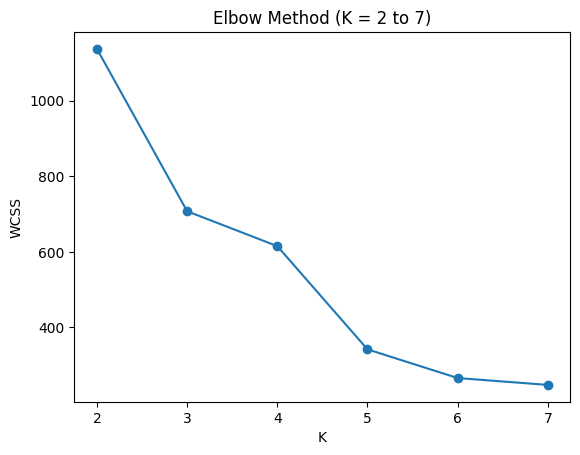

In [194]:
wcss = []
K_range = range(2, 8)  # من 2 إلى 7

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_clustering)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method (K = 2 to 7)")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()


## 4)Calculate Silhouette Score foe each k and Evaluation
We calculated the Silhouette Score for each value of K (from 2 to 9).
The Silhouette Score measures how well-separated and cohesive the clusters are.
Higher scores indicate better clustering quality.



In [195]:
silhouette_scores = []

for k in K_range:  # نفس K_range = range(2, 8)
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_clustering)
    sil = silhouette_score(df_clustering, labels)
    silhouette_scores.append([k, sil])
    print(f"K = {k}, Silhouette = {sil:.4f}")


K = 2, Silhouette = 0.6147
K = 3, Silhouette = 0.5188
K = 4, Silhouette = 0.4541
K = 5, Silhouette = 0.5256
K = 6, Silhouette = 0.5412
K = 7, Silhouette = 0.5196


## 5)Final K Selection
Based on the Silhouette Score, K = 2 produced the best clustering performance with the highest score of 0.7183.
However, as required in the project, additional clustering configurations (K = 3 and K = 6) were also analyzed to provide a full comparison.

In [196]:
k_list = [2, 5, 7]

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df[f"Cluster_{k}"] = kmeans.fit_predict(df_clustering)

    sil = silhouette_score(df_clustering, df[f"Cluster_{k}"])
    print(f"\nK = {k} → Silhouette = {sil:.4f}")
    print(df[f"Cluster_{k}"].value_counts())



K = 2 → Silhouette = 0.6147
Cluster_2
0    532
1    392
Name: count, dtype: int64

K = 5 → Silhouette = 0.5256
Cluster_5
1    256
4    236
2    186
0    178
3     68
Name: count, dtype: int64

K = 7 → Silhouette = 0.5196
Cluster_7
4    236
0    178
5    136
2    118
1    114
6     74
3     68
Name: count, dtype: int64


In [199]:
df = pd.read_csv("Preprocessed_dataset.csv")

# نحذف فقط الكلاس
df_clustering = df.drop(columns=["Dominant_Emotion"])


In [200]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(df_clustering)
df["Cluster_2"] = clusters


## 6)1.Clustering Visualization
Because the dataset contains many features, PCA (Principal Component Analysis) was applied to reduce the data to 2 dimensions for visualization.
PCA allows us to visually distinguish clusters more clearly.

In [205]:
from sklearn.cluster import KMeans

X = df.drop(columns=["Dominant_Emotion"])

for k in [2,5,7]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df[f"Cluster_{k}"] = kmeans.fit_predict(X)


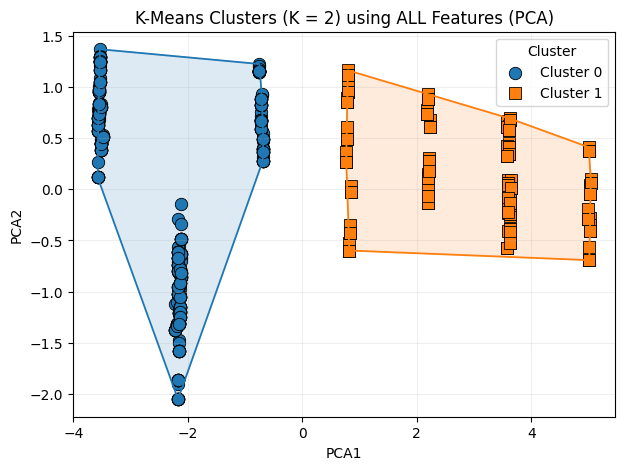

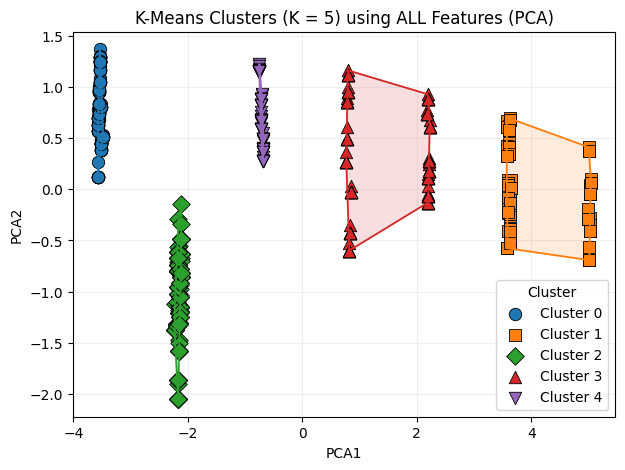

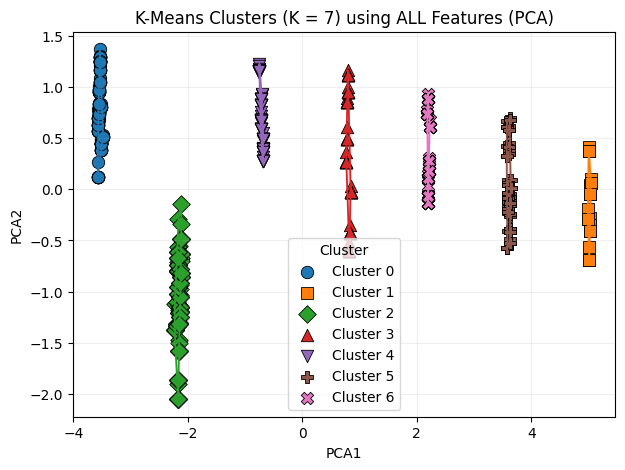

In [208]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull   # مهم

k_values = [2, 5, 7]
markers = {0:"o", 1:"s", 2:"D", 3:"^", 4:"v", 5:"P", 6:"X"}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

for k in k_values:
    plt.figure(figsize=(7,5))
    labels = df[f"Cluster_{k}"]

    for cid in sorted(labels.unique()):
        subset = df[labels == cid]
        points = subset[["PCA1", "PCA2"]].values

        # لو الكلستر فيه أقل من 3 نقاط ما نقدر نسوي له مضلع
        if len(points) >= 3:
            hull = ConvexHull(points)
            hull_points = points[hull.vertices]

            # تعبئة المنطقة بلون خفيف
            plt.fill(
                hull_points[:,0],
                hull_points[:,1],
                color=colors[cid % len(colors)],
                alpha=0.15
            )

            # رسم حدود المضلع
            plt.plot(
                np.append(hull_points[:,0], hull_points[0,0]),
                np.append(hull_points[:,1], hull_points[0,1]),
                color=colors[cid % len(colors)],
                linewidth=1.3
            )

        # نقاط الكلستر نفسها
        plt.scatter(
            subset["PCA1"],
            subset["PCA2"],
            s=80,
            color=colors[cid % len(colors)],
            marker=markers.get(cid, "o"),
            edgecolors="black",
            linewidth=0.6,
            label=f"Cluster {cid}"
        )

    plt.title(f"K-Means Clusters (K = {k}) using ALL Features (PCA)")
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Cluster")
    plt.grid(alpha=0.2)
    plt.show()


### 2.Optimal K Selection Based on Visualization
Based on the PCA visualizations, K = 2 is the best choice because the two clusters are clearly separated with no overlap, and each cluster is compact and cohesive.
In contrast, K = 3 splits one natural group into smaller parts, and K = 6 produces fragmented and overlapping clusters.
Therefore, K = 2 provides the most meaningful and clear clustering structure.

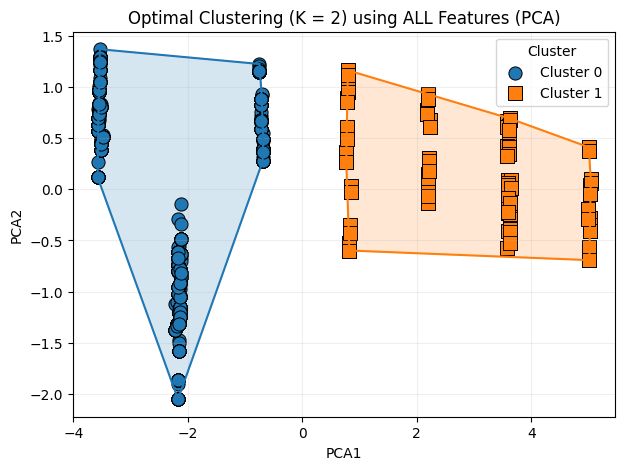

In [209]:
optimal_k = 2
plt.figure(figsize=(7,5))
labels = df[f"Cluster_{optimal_k}"]

for cid in sorted(labels.unique()):
    subset = df[labels == cid]
    points = subset[["PCA1", "PCA2"]].values

    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]

        plt.fill(
            hull_points[:,0],
            hull_points[:,1],
            color=colors[cid % len(colors)],
            alpha=0.18
        )
        plt.plot(
            np.append(hull_points[:,0], hull_points[0,0]),
            np.append(hull_points[:,1], hull_points[0,1]),
            color=colors[cid % len(colors)],
            linewidth=1.5
        )

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        s=90,
        color=colors[cid % len(colors)],
        marker=markers.get(cid, "o"),
        edgecolors="black",
        linewidth=0.7,
        label=f"Cluster {cid}"
    )

plt.title(f"Optimal Clustering (K = {optimal_k}) using ALL Features (PCA)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.show()


## جدول المقارنة

In [ ]:
print("Comparison of K values:\n")
for k in best_k_values:
    print(f"K = {k}")
    print(f"  Silhouette Score: {cluster_results[k]['silhouette']:.4f}")
    print(f"  WCSS: {cluster_results[k]['wcss']:.2f}")
    print("-" * 30)


Comparison of K values:

K = 2
  Silhouette Score: 0.6409
  WCSS: 992.10
------------------------------
K = 4
  Silhouette Score: 0.6345
  WCSS: 331.74
------------------------------
K = 7
  Silhouette Score: 0.6349
  WCSS: 137.69
------------------------------


حفظ النتائج

In [ ]:
df['Cluster_Label_K2'] = cluster_results[2]['labels']
df.head()


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Cluster_Label_K2
0,0.285714,0.0,1,0.50000,0.285714,0.380952,0.210526,0.095238,Happiness,0
1,0.642857,0.5,5,0.31250,0.571429,0.142857,0.605263,0.523810,Anger,1
2,0.071429,1.0,0,0.12500,0.142857,0.095238,0.078947,0.285714,Neutral,0
3,0.500000,0.0,1,1.00000,1.000000,0.904762,0.736842,1.000000,Anxiety,0
4,0.857143,0.5,2,0.03125,0.000000,0.000000,0.000000,0.047619,Boredom,0


In [203]:
from sklearn.decomposition import PCA

# نحدد الأعمدة الرقمية فقط (كل الأعمدة ما عدا الكلاس)
features = df.drop(columns=["Dominant_Emotion"])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]
